In [ ]:
USE_VIDEO = False   # 👈 turn video training ON/OFF

# ================================================================
# CELL 1 – IMPORTS & CONFIG
# ================================================================
import os
import cv2
import math
import random
import numpy as np
from typing import List

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ---- CONFIGURABLE PATHS & HYPERPARAMETERS ----
DATA_ROOT = "B:\\deepfake_detection\\deepfake_dataset"  # TODO: change this to your dataset root

IMG_SIZE = 128          # Smaller for faster training
BATCH_SIZE_IMG = 32
BATCH_SIZE_VID = 4
NUM_FRAMES = 16         # Frames per video for training
EPOCHS_IMG = 10
EPOCHS_VID = 10
LEARNING_RATE = 1e-3

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)


# ================================================================
# CELL 2 – BASIC UTILS
# ================================================================
def detect_file_type(path: str) -> str:
    ext = path.split(".")[-1].lower()
    if ext in ["jpg", "jpeg", "png", "bmp", "webp"]:
        return "image"
    elif ext in ["mp4", "avi", "mov", "mkv"]:
        return "video"
    return "invalid"


# Simple transform (no pretrained normalization)
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
])


# ================================================================
# CELL 3 – IMAGE DATASET
# ================================================================
class ImageDeepfakeDataset(Dataset):
    """
    Expects:
        root/split/images/real/*.jpg
        root/split/images/fake/*.jpg
    split: 'train' or 'val'
    """
    def __init__(self, root: str, split: str = "train", transform=None):
        self.root = root
        self.split = split
        self.transform = transform if transform is not None else img_transform

        self.samples = []  # (path, label)
        base_dir = os.path.join(root, split, "images")
        for label_name, label in [("real", 0), ("fake", 1)]:
            class_dir = os.path.join(base_dir, label_name)
            if not os.path.isdir(class_dir):
                continue
            for fname in os.listdir(class_dir):
                fpath = os.path.join(class_dir, fname)
                if detect_file_type(fpath) == "image":
                    self.samples.append((fpath, label))

        print(f"[ImageDeepfakeDataset] {split}: {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path)
        if img is None:
            raise RuntimeError(f"Failed to read image: {path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.transform(img)
        label = torch.tensor(label, dtype=torch.float32)
        return img, label


# ================================================================
# CELL 4 – VIDEO DATASET
# ================================================================
class VideoDeepfakeDataset(Dataset):
    """
    Expects:
        root/split/videos/real/*.mp4
        root/split/videos/fake/*.mp4
    Each item returns:
        tensor of shape (NUM_FRAMES, 3, H, W), label
    """
    def __init__(self, root: str, split: str = "train", transform=None, num_frames: int = NUM_FRAMES):
        self.root = root
        self.split = split
        self.transform = transform if transform is not None else img_transform
        self.num_frames = num_frames

        self.samples = []  # (path, label)
        base_dir = os.path.join(root, split, "videos")
        for label_name, label in [("real", 0), ("fake", 1)]:
            class_dir = os.path.join(base_dir, label_name)
            if not os.path.isdir(class_dir):
                continue
            for fname in os.listdir(class_dir):
                fpath = os.path.join(class_dir, fname)
                if detect_file_type(fpath) == "video":
                    self.samples.append((fpath, label))

        print(f"[VideoDeepfakeDataset] {split}: {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def _sample_frame_indices(self, total_frames: int) -> List[int]:
        if total_frames <= 0:
            return [0] * self.num_frames
        if total_frames <= self.num_frames:
            idxs = list(range(total_frames))
            while len(idxs) < self.num_frames:
                idxs.append(total_frames - 1)
            return idxs
        step = total_frames / float(self.num_frames)
        return [int(i * step) for i in range(self.num_frames)]

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        cap = cv2.VideoCapture(path)

        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frame_idxs = self._sample_frame_indices(total)

        frames = []
        for fi in frame_idxs:
            cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
            ret, frame = cap.read()
            if not ret:
                if len(frames) > 0:
                    frame = frames[-1]
                else:
                    frame = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = self.transform(frame)
            frames.append(frame)

        cap.release()
        frames = torch.stack(frames, dim=0)  # (T, C, H, W)
        label = torch.tensor(label, dtype=torch.float32)
        return frames, label


# ================================================================
# CELL 5 – MODELS FROM SCRATCH
# ================================================================
class SimpleCNN(nn.Module):
    """
    Simple CNN backbone for image feature extraction / classification.
    From scratch – no pretrained components.
    """
    def __init__(self, in_channels=3, feature_dim=256):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),      # 64x64

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),      # 32x32

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),      # 16x16

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))  # 1x1
        )
        self.fc = nn.Linear(256, feature_dim)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


class ImageClassifier(nn.Module):
    """
    Uses SimpleCNN as backbone.
    Output: single sigmoid value (real/fake probability).
    """
    def __init__(self, feature_dim=256):
        super().__init__()
        self.backbone = SimpleCNN(in_channels=3, feature_dim=feature_dim)
        self.head = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Linear(feature_dim, 1)
        )

    def forward(self, x):
        feat = self.backbone(x)
        logit = self.head(feat)
        prob = torch.sigmoid(logit)
        return prob.squeeze(1)


class VideoClassifier(nn.Module):
    """
    Video model:
    - Frame-level features from the same SimpleCNN backbone
    - LSTM over temporal dimension
    - Sigmoid output (real/fake probability)
    """
    def __init__(self, feature_dim=256, hidden_dim=128, num_layers=1, bidirectional=False):
        super().__init__()
        self.backbone = SimpleCNN(in_channels=3, feature_dim=feature_dim)
        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional
        )
        lstm_out_dim = hidden_dim * (2 if bidirectional else 1)
        self.head = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Linear(lstm_out_dim, 1)
        )

    def forward(self, x):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        feat = self.backbone(x)           # (B*T, F)
        feat = feat.view(B, T, -1)        # (B, T, F)
        lstm_out, _ = self.lstm(feat)     # (B, T, H)
        last = lstm_out[:, -1, :]         # (B, H)
        logit = self.head(last)
        prob = torch.sigmoid(logit)
        return prob.squeeze(1)


# Instantiate models
image_model = ImageClassifier().to(DEVICE)
video_model = VideoClassifier().to(DEVICE)

print("Image model params:", sum(p.numel() for p in image_model.parameters())/1e6, "M")
print("Video model params:", sum(p.numel() for p in video_model.parameters())/1e6, "M")


# ================================================================
# CELL 6 – TRAINING UTILITIES
# ================================================================
def train_epoch_image(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)            # (B,)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = (outputs >= 0.5).float()
        total_correct += (preds == labels).sum().item()
        total += imgs.size(0)

    avg_loss = total_loss / total if total > 0 else 0
    acc = total_correct / total if total > 0 else 0
    return avg_loss, acc


def eval_epoch_image(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            preds = (outputs >= 0.5).float()
            total_correct += (preds == labels).sum().item()
            total += imgs.size(0)

    avg_loss = total_loss / total if total > 0 else 0
    acc = total_correct / total if total > 0 else 0
    return avg_loss, acc


def train_epoch_video(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for frames, labels in loader:
        frames = frames.to(DEVICE)   # (B, T, C, H, W)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(frames)      # (B,)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * frames.size(0)
        preds = (outputs >= 0.5).float()
        total_correct += (preds == labels).sum().item()
        total += frames.size(0)

    avg_loss = total_loss / total if total > 0 else 0
    acc = total_correct / total if total > 0 else 0
    return avg_loss, acc


def eval_epoch_video(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for frames, labels in loader:
            frames = frames.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(frames)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * frames.size(0)
            preds = (outputs >= 0.5).float()
            total_correct += (preds == labels).sum().item()
            total += frames.size(0)

    avg_loss = total_loss / total if total > 0 else 0
    acc = total_correct / total if total > 0 else 0
    return avg_loss, acc


# ================================================================
# CELL 7 – PREPARE DATALOADERS
# ================================================================
# ================================================================
# CELL 7 – PREPARE DATALOADERS
# ================================================================

# Image loaders (UNCHANGED)
train_img_ds = ImageDeepfakeDataset(DATA_ROOT, split="train")
val_img_ds   = ImageDeepfakeDataset(DATA_ROOT, split="val")

assert len(train_img_ds) > 0, "❌ No training images found"
assert len(val_img_ds) > 0, "❌ No validation images found"

train_img_loader = DataLoader(
    train_img_ds,
    batch_size=BATCH_SIZE_IMG,
    shuffle=True,
    num_workers=0,   # Windows-safe
    pin_memory=True
)

val_img_loader = DataLoader(
    val_img_ds,
    batch_size=BATCH_SIZE_IMG,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# ---------------- VIDEO LOADERS (OPTIONAL) ----------------
if USE_VIDEO:
    train_vid_ds = VideoDeepfakeDataset(DATA_ROOT, split="train")
    val_vid_ds   = VideoDeepfakeDataset(DATA_ROOT, split="val")

    assert len(train_vid_ds) > 0, "❌ No training videos found"
    assert len(val_vid_ds) > 0, "❌ No validation videos found"

    train_vid_loader = DataLoader(
        train_vid_ds,
        batch_size=BATCH_SIZE_VID,
        shuffle=True,
        num_workers=0,
        pin_memory=True
    )

    val_vid_loader = DataLoader(
        val_vid_ds,
        batch_size=BATCH_SIZE_VID,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )
else:
    print("⚠️ Video training skipped (USE_VIDEO=False)")

# ================================================================
# CELL 8 – TRAIN IMAGE MODEL
# ================================================================
criterion_img = nn.BCELoss()
optimizer_img = optim.Adam(image_model.parameters(), lr=LEARNING_RATE)

# Per-epoch history (used by the metrics cell)
train_loss_history, val_loss_history = [], []
train_acc_history,  val_acc_history  = [], []

best_val_acc_img = 0.0
for epoch in range(1, EPOCHS_IMG + 1):
    train_loss, train_acc = train_epoch_image(image_model, train_img_loader, optimizer_img, criterion_img)
    val_loss,   val_acc   = eval_epoch_image(image_model, val_img_loader, criterion_img)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f"[Image] Epoch {epoch}/{EPOCHS_IMG} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc_img:
        best_val_acc_img = val_acc
        torch.save(image_model.state_dict(), "image_model_best.pth")
        print("  -> Saved best image model.")

print("Best Image Val Acc:", best_val_acc_img)


# ── Save training history for the metrics cell ───────────────────────────
import json as _json
_history = {
    'train_loss': train_loss_history,
    'val_loss':   val_loss_history,
    'train_acc':  train_acc_history,
    'val_acc':    val_acc_history,
}
with open('training_history.json', 'w') as _f:
    _json.dump(_history, _f)
print('💾 History saved to training_history.json')


# ================================================================
# CELL 9 – TRAIN VIDEO MODEL
# ================================================================
# ================================================================
# CELL 9 – TRAIN VIDEO MODEL
# ================================================================
if USE_VIDEO:
    criterion_vid = nn.BCELoss()
    optimizer_vid = optim.Adam(video_model.parameters(), lr=LEARNING_RATE)

    best_val_acc_vid = 0.0
    for epoch in range(1, EPOCHS_VID + 1):
        train_loss, train_acc = train_epoch_video(
            video_model, train_vid_loader, optimizer_vid, criterion_vid
        )
        val_loss, val_acc = eval_epoch_video(
            video_model, val_vid_loader, criterion_vid
        )

        print(f"[Video] Epoch {epoch}/{EPOCHS_VID} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc_vid:
            best_val_acc_vid = val_acc
            torch.save(video_model.state_dict(), "video_model_best.pth")
            print("  -> Saved best video model.")

    print("Best Video Val Acc:", best_val_acc_vid)
else:
    print("⚠️ Video training skipped.")



# ================================================================
# CELL 10 – UNIFIED INFERENCE (IMAGE + VIDEO)
# ================================================================
def preprocess_single_image(path: str):
    img = cv2.imread(path)
    if img is None:
        raise RuntimeError(f"Can't read image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img_transform(img)
    return img.unsqueeze(0).to(DEVICE)  # (1, 3, H, W)


def extract_frames_for_inference(path: str, num_frames: int = NUM_FRAMES):
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        raise RuntimeError(f"Invalid or empty video: {path}")

    def sample_idxs(total_frames, n):
        if total_frames <= n:
            idxs = list(range(total_frames))
            while len(idxs) < n:
                idxs.append(total_frames - 1)
            return idxs
        step = total_frames / float(n)
        return [int(i * step) for i in range(n)]

    idxs = sample_idxs(total, num_frames)
    frames = []
    for fi in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, frame = cap.read()
        if not ret:
            if len(frames) > 0:
                frame = frames[-1]
            else:
                frame = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = img_transform(frame)
        frames.append(frame)
    cap.release()

    frames = torch.stack(frames, dim=0)  # (T, C, H, W)
    return frames.unsqueeze(0).to(DEVICE)  # (1, T, C, H, W)


def unified_predict(path: str,
                    image_model_ckpt: str = "image_model_best.pth",
                    video_model_ckpt: str = "video_model_best.pth"):
    ftype = detect_file_type(path)

    # Load weights (you can load once outside this function if you want)
    image_model = ImageClassifier().to(DEVICE)
    video_model = VideoClassifier().to(DEVICE)
    if os.path.isfile(image_model_ckpt):
        image_model.load_state_dict(torch.load(image_model_ckpt, map_location=DEVICE))
    if os.path.isfile(video_model_ckpt):
        video_model.load_state_dict(torch.load(video_model_ckpt, map_location=DEVICE))
    image_model.eval()
    video_model.eval()

    if ftype == "image":
        x = preprocess_single_image(path)
        with torch.no_grad():
            prob_fake = image_model(x).item()
        return {
            "file_type": "image",
            "fake_probability": float(prob_fake),
            "real_probability": float(1.0 - prob_fake)
        }

    elif ftype == "video":
        x = extract_frames_for_inference(path, num_frames=NUM_FRAMES)
        with torch.no_grad():
            prob_fake = video_model(x).item()
        return {
            "file_type": "video",
            "fake_probability": float(prob_fake),
            "real_probability": float(1.0 - prob_fake)
        }

    else:
        raise ValueError("Unsupported file format for unified_predict().")




Using device: cpu
Image model params: 0.455425 M
Video model params: 0.652929 M
[ImageDeepfakeDataset] train: 9954 samples
[ImageDeepfakeDataset] val: 9954 samples
⚠️ Video training skipped (USE_VIDEO=False)
[Image] Epoch 1/10 | Train Loss: 0.4681, Train Acc: 0.7790 | Val Loss: 0.3694, Val Acc: 0.8348
  -> Saved best image model.
[Image] Epoch 2/10 | Train Loss: 0.3691, Train Acc: 0.8324 | Val Loss: 0.3395, Val Acc: 0.8510
  -> Saved best image model.
[Image] Epoch 3/10 | Train Loss: 0.3133, Train Acc: 0.8641 | Val Loss: 0.2713, Val Acc: 0.8848
  -> Saved best image model.
[Image] Epoch 4/10 | Train Loss: 0.2793, Train Acc: 0.8803 | Val Loss: 0.5362, Val Acc: 0.7846
[Image] Epoch 5/10 | Train Loss: 0.2685, Train Acc: 0.8843 | Val Loss: 0.3889, Val Acc: 0.8361
[Image] Epoch 6/10 | Train Loss: 0.2392, Train Acc: 0.9013 | Val Loss: 0.6448, Val Acc: 0.7143
[Image] Epoch 7/10 | Train Loss: 0.2253, Train Acc: 0.9027 | Val Loss: 0.3568, Val Acc: 0.8532
[Image] Epoch 8/10 | Train Loss: 0.2187,

In [2]:
# ================================================================
# CELL 2 – SELF-CONTAINED INFERENCE (run without re-training)
# Loads saved checkpoint and predicts on a single image or video.
# ================================================================
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE   = 128
NUM_FRAMES = 16

img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
])

# ── model definitions ────────────────────────────────────────────
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=3, feature_dim=256):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),           nn.BatchNorm2d(64),  nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),          nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1),         nn.BatchNorm2d(256), nn.ReLU(True), nn.AdaptiveAvgPool2d((1,1)),
        )
        self.fc = nn.Linear(256, feature_dim)
    def forward(self, x):
        return self.fc(self.features(x).view(x.size(0), -1))

class ImageClassifier(nn.Module):
    def __init__(self, feature_dim=256):
        super().__init__()
        self.backbone = SimpleCNN(3, feature_dim)
        self.head = nn.Sequential(nn.ReLU(True), nn.Linear(feature_dim, 1))
    def forward(self, x):
        return torch.sigmoid(self.head(self.backbone(x))).squeeze(1)

class VideoClassifier(nn.Module):
    def __init__(self, feature_dim=256, hidden_dim=128, num_layers=1, bidirectional=False):
        super().__init__()
        self.backbone = SimpleCNN(3, feature_dim)
        self.lstm = nn.LSTM(feature_dim, hidden_dim, num_layers, batch_first=True, bidirectional=bidirectional)
        self.head = nn.Sequential(nn.ReLU(True), nn.Linear(hidden_dim * (2 if bidirectional else 1), 1))
    def forward(self, x):
        B, T, C, H, W = x.shape
        feat = self.backbone(x.view(B*T, C, H, W)).view(B, T, -1)
        out, _ = self.lstm(feat)
        return torch.sigmoid(self.head(out[:, -1, :])).squeeze(1)

# ── helpers ──────────────────────────────────────────────────────
def detect_file_type(path):
    ext = path.split(".")[-1].lower()
    if ext in ["jpg","jpeg","png","bmp","webp"]: return "image"
    if ext in ["mp4","avi","mov","mkv"]:         return "video"
    return "invalid"

def preprocess_single_image(path):
    img = cv2.imread(path)
    if img is None:
        raise RuntimeError(f"Can't read image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img_transform(img).unsqueeze(0).to(DEVICE)

def extract_frames_for_inference(path, num_frames=NUM_FRAMES):
    cap   = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        raise RuntimeError(f"Invalid or empty video: {path}")
    idxs = list(range(total)) if total <= num_frames else [int(i * total / num_frames) for i in range(num_frames)]
    while len(idxs) < num_frames:
        idxs.append(total - 1)
    frames = []
    for fi in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, frame = cap.read()
        if not ret:
            frame = frames[-1] if frames else np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        frames.append(img_transform(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
    cap.release()
    return torch.stack(frames).unsqueeze(0).to(DEVICE)  # (1,T,C,H,W)

def unified_predict(path,
                    image_model_ckpt="image_model_best.pth",
                    video_model_ckpt="video_model_best.pth"):
    ftype = detect_file_type(path)
    if ftype == "image":
        model = ImageClassifier().to(DEVICE)
        if os.path.isfile(image_model_ckpt):
            model.load_state_dict(torch.load(image_model_ckpt, map_location=DEVICE))
        model.eval()
        with torch.no_grad():
            prob_fake = model(preprocess_single_image(path)).item()
        return {"file_type": "image", "fake_probability": prob_fake, "real_probability": 1.0 - prob_fake}
    elif ftype == "video":
        model = VideoClassifier().to(DEVICE)
        if os.path.isfile(video_model_ckpt):
            model.load_state_dict(torch.load(video_model_ckpt, map_location=DEVICE))
        model.eval()
        with torch.no_grad():
            prob_fake = model(extract_frames_for_inference(path)).item()
        return {"file_type": "video", "fake_probability": prob_fake, "real_probability": 1.0 - prob_fake}
    else:
        raise ValueError("Unsupported file format for unified_predict().")

def explain_result(result):
    prob  = result["fake_probability"]
    label = "FAKE" if prob >= 0.5 else "REAL"
    conf  = prob if label == "FAKE" else result["real_probability"]
    print("File Type :", result["file_type"])
    print("Prediction:", label)
    print("Confidence:", f"{conf*100:.2f}%")

# ── run ──────────────────────────────────────────────────────────
result = unified_predict(r"B:\deepfake_detection\test_images\test_1.png")
explain_result(result)


File Type : image
Prediction: FAKE
Confidence: 71.13%


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_3356\2036138348.py:95: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(image_model_ckpt, map_lo

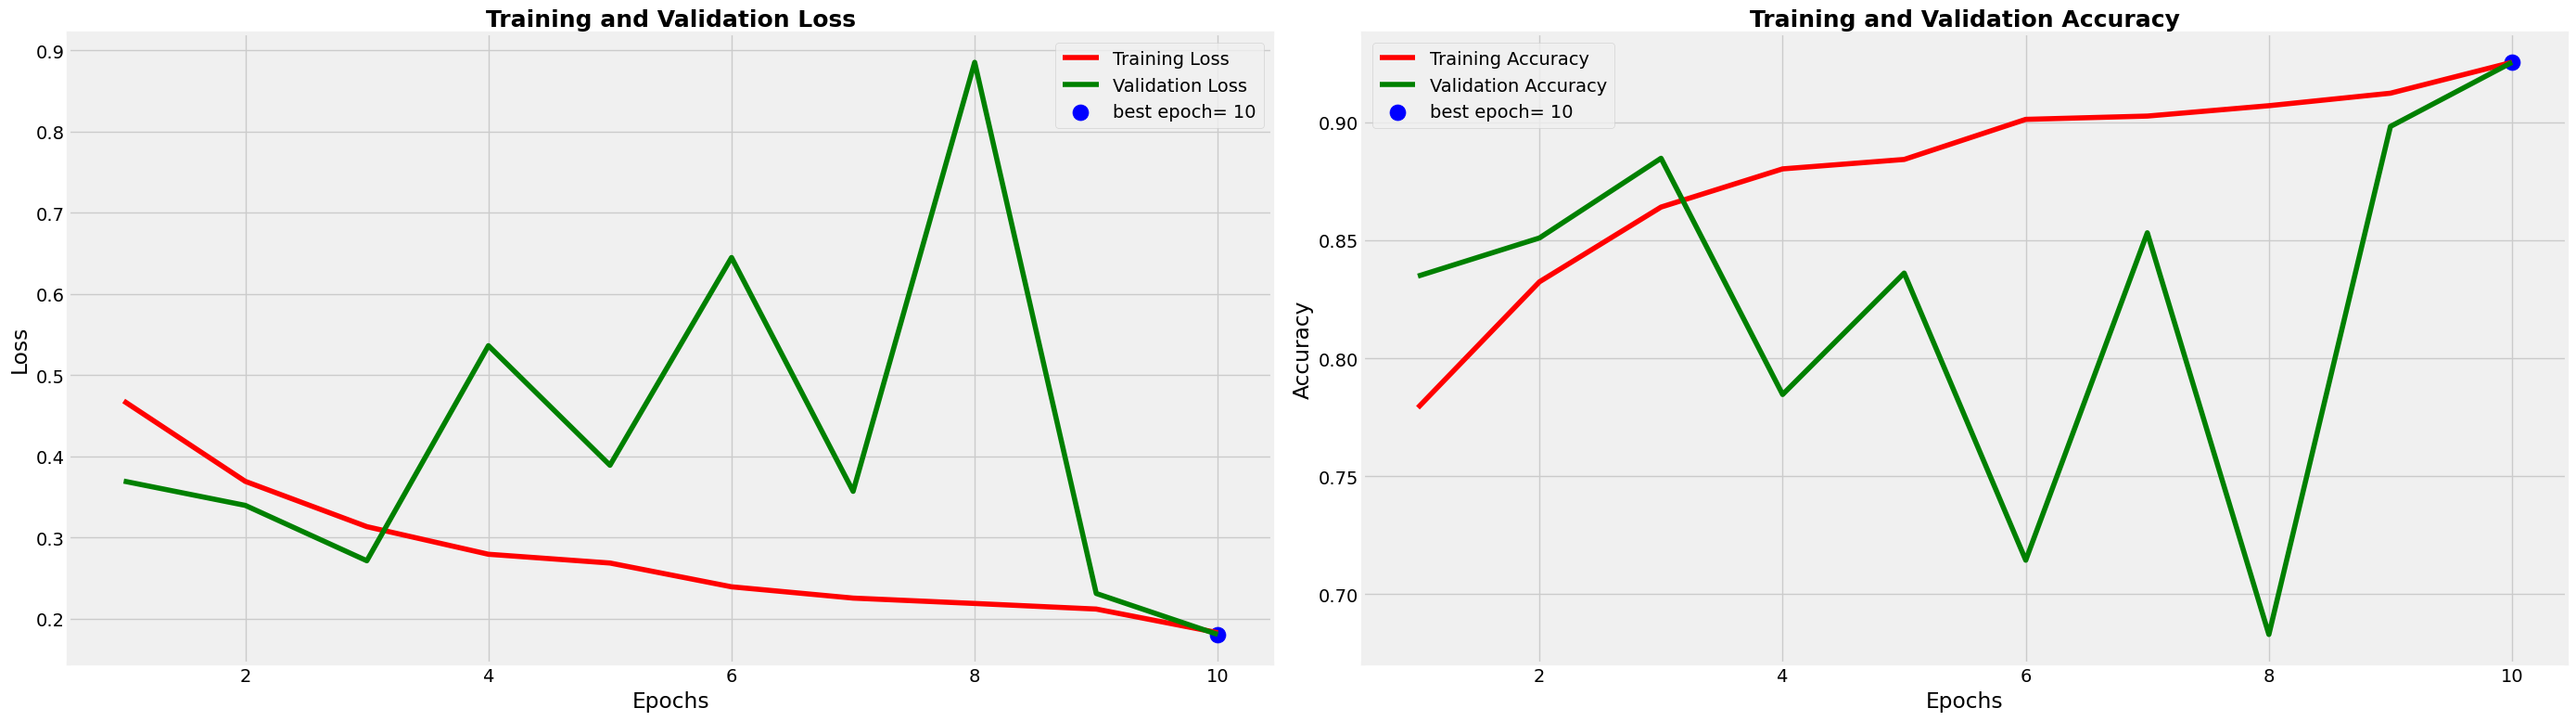

C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_3356\3432771352.py:100: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('image_model_best.pth',

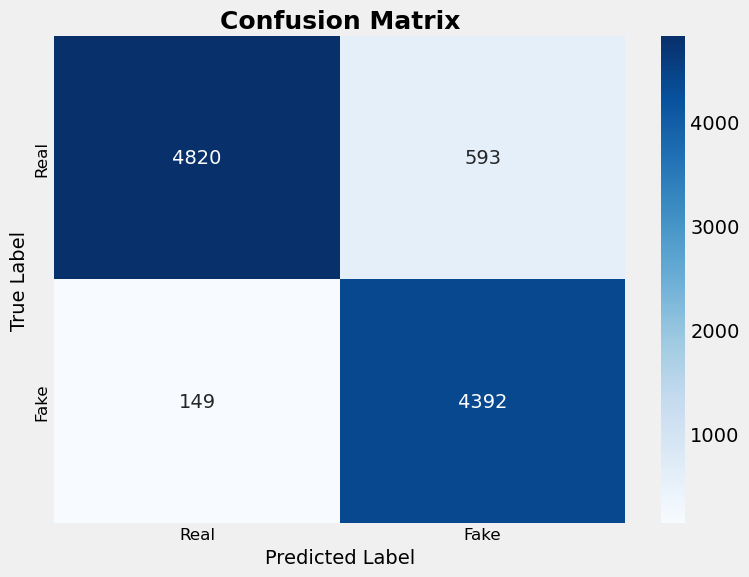

Accuracy Score : 0.9255
Best Val Acc   : 0.9255  (epoch 10)
Best Val Loss  : 0.1805  (epoch 10)

Classification Report:
              precision    recall  f1-score   support

        Real       0.97      0.89      0.93      5413
        Fake       0.88      0.97      0.92      4541

    accuracy                           0.93      9954
   macro avg       0.93      0.93      0.93      9954
weighted avg       0.93      0.93      0.93      9954



In [3]:
# ================================================================
# CELL 3 – METRICS & VISUALISATION  (self-contained)
# Run at any time after Cell 1 has trained at least once.
# Reads training_history.json + image_model_best.pth from disk.
# ================================================================
import os, json, cv2, numpy as np
import torch, torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 128
DATA_ROOT      = r'B:\deepfake_detection\deepfake_dataset'
BATCH_SIZE_IMG = 32

img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
])

# ── model (must match Cell 1 architecture) ──────────────────────
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=3, feature_dim=256):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(True),nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),          nn.BatchNorm2d(64),nn.ReLU(True),nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1),         nn.BatchNorm2d(128),nn.ReLU(True),nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1),        nn.BatchNorm2d(256),nn.ReLU(True),nn.AdaptiveAvgPool2d((1,1)),
        )
        self.fc = nn.Linear(256, feature_dim)
    def forward(self, x): return self.fc(self.features(x).view(x.size(0),-1))

class ImageClassifier(nn.Module):
    def __init__(self, feature_dim=256):
        super().__init__()
        self.backbone = SimpleCNN(3, feature_dim)
        self.head = nn.Sequential(nn.ReLU(True), nn.Linear(feature_dim, 1))
    def forward(self, x): return torch.sigmoid(self.head(self.backbone(x))).squeeze(1)

# ── val dataset ─────────────────────────────────────────────────
class ImageDeepfakeDataset(Dataset):
    def __init__(self, root, split='val', transform=None):
        self.transform = transform or img_transform
        self.samples = []
        base = os.path.join(root, split, 'images')
        for name, lbl in [('real',0),('fake',1)]:
            d = os.path.join(base, name)
            if not os.path.isdir(d): continue
            for f in os.listdir(d):
                if f.split('.')[-1].lower() in ['jpg','jpeg','png','bmp','webp']:
                    self.samples.append((os.path.join(d,f), lbl))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        p, lbl = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        return self.transform(img), torch.tensor(lbl, dtype=torch.float32)

# ── 1. Load history ──────────────────────────────────────────────
with open('training_history.json') as f:
    h = json.load(f)

train_loss_history = h['train_loss']
val_loss_history   = h['val_loss']
train_acc_history  = h['train_acc']
val_acc_history    = h['val_acc']

Epochs      = [i+1 for i in range(len(train_acc_history))]
idx_loss    = int(np.argmin(val_loss_history))
idx_acc     = int(np.argmax(val_acc_history))
val_lowest  = val_loss_history[idx_loss]
val_highest = val_acc_history[idx_acc]

# ── 2. Training curves ───────────────────────────────────────────
plt.figure(figsize=(28,8))
plt.style.use('fivethirtyeight')

plt.subplot(1,2,1)
plt.plot(Epochs, train_loss_history, 'r', label='Training Loss')
plt.plot(Epochs, val_loss_history,   'g', label='Validation Loss')
plt.scatter(idx_loss+1, val_lowest,  s=150, c='blue', label=f'best epoch= {idx_loss+1}')
plt.title('Training and Validation Loss', fontweight='bold', fontsize=18)
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs, train_acc_history, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc_history,   'g', label='Validation Accuracy')
plt.scatter(idx_acc+1, val_highest, s=150, c='blue', label=f'best epoch= {idx_acc+1}')
plt.title('Training and Validation Accuracy', fontweight='bold', fontsize=18)
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

plt.tight_layout()
plt.show()

# ── 3. Confusion matrix on validation set ────────────────────────
model = ImageClassifier().to(DEVICE)
model.load_state_dict(torch.load('image_model_best.pth', map_location=DEVICE))
model.eval()

val_ds     = ImageDeepfakeDataset(DATA_ROOT, split='val')
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE_IMG, shuffle=False, num_workers=0)

y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        probs = model(imgs.to(DEVICE)).cpu().numpy()
        y_true.extend(labels.numpy().astype(int).tolist())
        y_pred.extend((probs >= 0.5).astype(int).tolist())

y_true, y_pred = np.array(y_true), np.array(y_pred)
class_names = ['Real', 'Fake']

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_true,y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=18, weight='bold')
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(fontsize=12); plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# ── 4. Scalar metrics ────────────────────────────────────────────
print(f'Accuracy Score : {accuracy_score(y_true,y_pred):.4f}')
print(f'Best Val Acc   : {val_highest:.4f}  (epoch {idx_acc+1})')
print(f'Best Val Loss  : {val_lowest:.4f}  (epoch {idx_loss+1})')
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))
